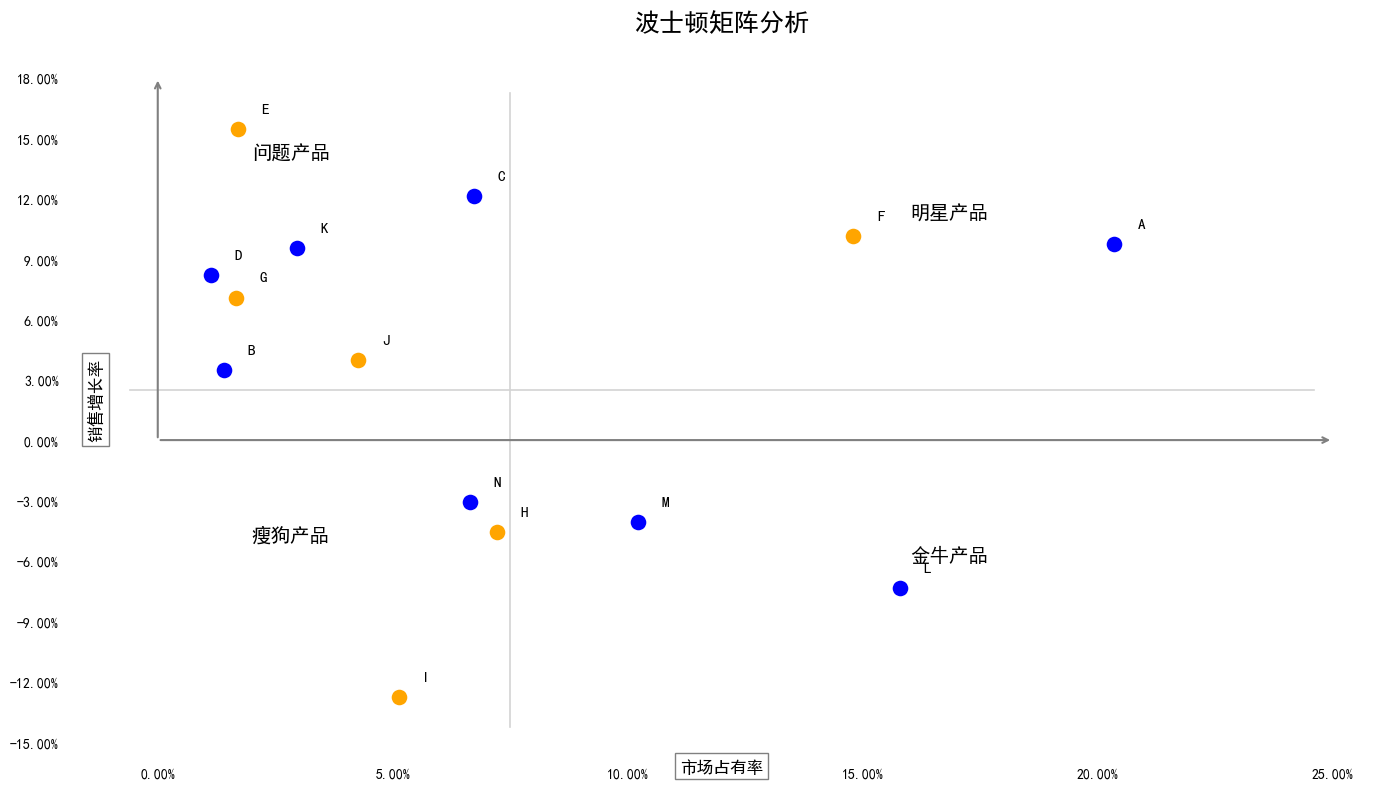

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
#1-1波士顿矩阵
# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据：(销售额占比/市场占有率, 销售额环比/销售增长率)
data = {
    'A': (20.34, 9.76, 'blue'),
    'B': (1.41, 3.48, 'blue'),
    'C': (6.73, 12.14, 'blue'),
    'D': (1.13, 8.21, 'blue'),
    'E': (1.70, 15.45, 'orange'),
    'F': (14.80, 10.14, 'orange'),
    'G': (1.66, 7.08, 'orange'),
    'H': (7.22, -4.56, 'orange'),
    'I': (5.13, -12.77, 'orange'),
    'J': (4.27, 3.98, 'orange'),
    'K': (2.96, 9.54, 'blue'),
    'L': (15.79, -7.35, 'blue'),
    'M': (10.21, -4.06, 'blue'),
    'N': (6.64, -3.09, 'blue'),
}

# 分界线
x_threshold = 7.5
y_threshold = 2.5

fig, ax = plt.subplots(figsize=(14, 8))

# 绘制坐标轴箭头
ax.annotate('', xy=(25, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('', xy=(0, 18), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# 绘制分界线
ax.axhline(y=y_threshold, color='lightgray', linestyle='-', linewidth=1.2, xmin=0.05, xmax=0.95)
ax.axvline(x=x_threshold, color='lightgray', linestyle='-', linewidth=1.2, ymin=0.05, ymax=0.95)

# 绘制数据点
for label, (x, y, color) in data.items():
    ax.scatter(x, y, s=150, color=color, zorder=5, edgecolors='white', linewidth=1)
    ax.annotate(label, xy=(x, y), xytext=(x + 0.5, y + 0.8),
                fontsize=11, fontweight='bold', color='black')

# 象限标签
ax.text(16, 11, '明星产品', fontsize=14, fontweight='bold', color='black')
ax.text(2, 14, '问题产品', fontsize=14, fontweight='bold', color='black')
ax.text(16, -6, '金牛产品', fontsize=14, fontweight='bold', color='black')
ax.text(2, -5, '瘦狗产品', fontsize=14, fontweight='bold', color='black')

# 轴标签
ax.text(12, -16.5, '市场占有率', fontsize=12, ha='center',
        bbox=dict(boxstyle='square', facecolor='white', edgecolor='gray'))
ax.text(-1.5, 2, '销售增长率', fontsize=12, rotation=90, va='center',
        bbox=dict(boxstyle='square', facecolor='white', edgecolor='gray'))

# 标题
ax.set_title('波士顿矩阵分析', fontsize=18, fontweight='bold', pad=20)

# 设置坐标轴范围
ax.set_xlim(-2, 26)
ax.set_ylim(-16, 19)

# 设置刻度
ax.set_xticks([0, 5, 10, 15, 20, 25])
ax.set_xticklabels(['0.00%', '5.00%', '10.00%', '15.00%', '20.00%', '25.00%'])
ax.set_yticks([-15, -12, -9, -6, -3, 0, 3, 6, 9, 12, 15, 18])
ax.set_yticklabels(['-15.00%', '-12.00%', '-9.00%', '-6.00%', '-3.00%',
                     '0.00%', '3.00%', '6.00%', '9.00%', '12.00%', '15.00%', '18.00%'])

# 隐藏默认边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
plt.savefig('boston_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


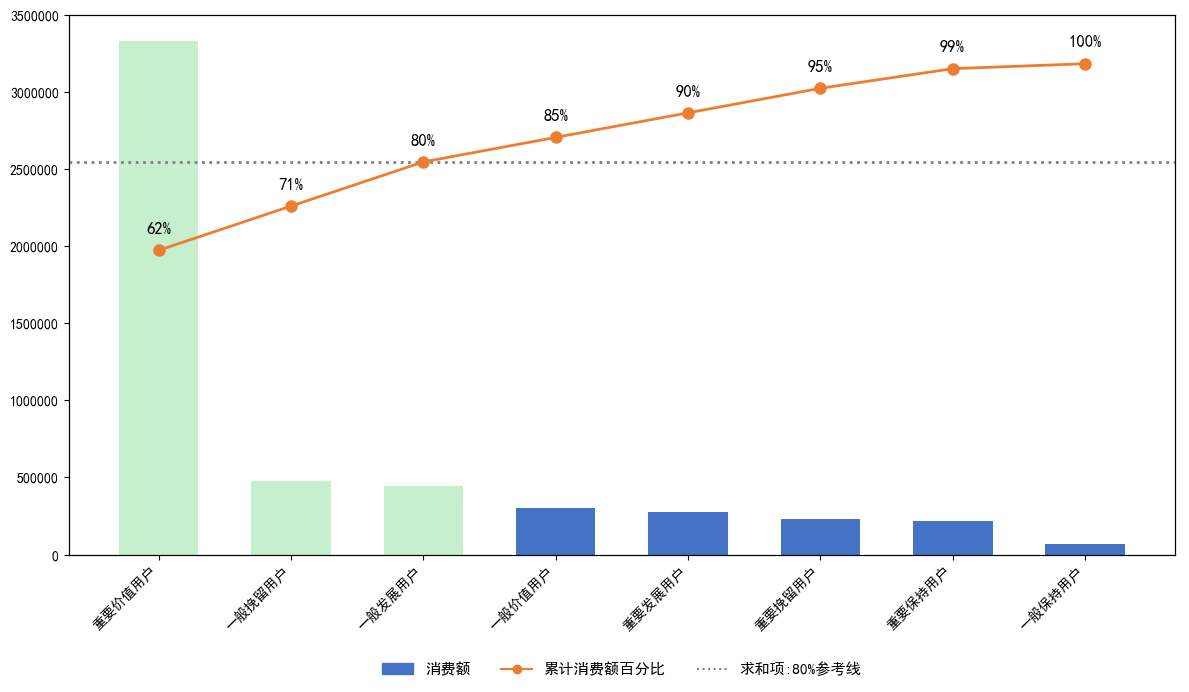

In [1]:
import matplotlib.pyplot as plt
import numpy as np
#1-2 RFM模型
# ================= 1. 全局设置 =================
# 设置中文字体 (Windows用SimHei，Mac用Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# ================= 2. 数据准备 =================
categories = ['重要价值用户', '一般挽留用户', '一般发展用户', '一般价值用户', 
              '重要发展用户', '重要挽留用户', '重要保持用户', '一般保持用户']

# 消费额 (左轴数据)
consumption = [3332337.04, 474480.41, 442203.79, 300764.97, 
               274398.75, 228826.03, 215488.51, 67686.6]

# 累计百分比 (右轴数据)
cumulative_pct = [0.62, 0.71, 0.80, 0.85, 0.90, 0.95, 0.99, 1.00]

# ================= 3. 绘图 =================
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 颜色定义 (模仿 Excel 风格) ---
color_green = '#C6EFCE'  # 浅绿色 (前80%部分)
color_blue = '#4472C4'   # 蓝色 (剩余部分)
color_orange = '#ED7D31' # 橙色 (折线)

# 为柱子设置颜色：前3个是绿色，后面是蓝色
bar_colors = [color_green, color_green, color_green] + [color_blue] * 5

# --- 绘制柱状图 (左轴) ---
x_pos = np.arange(len(categories))
bars = ax1.bar(x_pos, consumption, color=bar_colors, width=0.6, label='消费额', zorder=2)

# 设置左轴 Y 轴范围 (0 到 3500万，步长 500万)
ax1.set_ylim(0, 3500000)
ax1.set_yticks(range(0, 3500001, 500000))
# 格式化左轴标签 (去掉小数，显示整数)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# --- 绘制折线图 (右轴) ---
ax2 = ax1.twinx()
line = ax2.plot(x_pos, cumulative_pct, color=color_orange, marker='o', linewidth=2, markersize=8, label='累计消费额百分比', zorder=3)

# 设置右轴 Y 轴范围 (0 到 1.0 或 1.2，为了留出标签空间)
ax2.set_ylim(0, 1.1) 
# 格式化右轴标签为百分比 (虽然图中主要靠文字标签，但轴刻度也可以设)
# 这里为了完全复刻，我们隐藏右轴的刻度标签，只保留左轴和文字标签，或者保留简单的刻度
ax2.set_yticks([]) # 隐藏右轴刻度，让图表更干净，像截图一样

# --- 绘制 80% 参考线 ---
# 在 y=0.8 处画一条灰色虚线
ax2.axhline(y=0.80, color='grey', linestyle=':', linewidth=2, label='求和项:80%参考线', zorder=1)

# --- 添加数据标签 (折线上方的百分比) ---
for i, v in enumerate(cumulative_pct):
    # 在折线点上方添加文字
    ax2.text(i, v + 0.03, f'{int(v*100)}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# --- 设置 X 轴 ---
ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories, rotation=45, ha='right', fontsize=10) # 旋转标签

# --- 添加图例 ---
# 合并图例句柄
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# 注意：axhline 的 label 需要手动处理或者通过 ax2 获取
# 这里我们手动构建图例
ax1.legend(handles=[
    plt.Rectangle((0,0),1,1, color=color_blue, label='消费额'),
    plt.Line2D([0], [0], color=color_orange, marker='o', label='累计消费额百分比'),
    plt.Line2D([0], [0], color='grey', linestyle=':', label='求和项:80%参考线')
], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False, fontsize=11)

# 添加标题 (可选，截图左上角有筛选器样式的文字，这里用标题模拟)
# plt.title('用户类别消费额帕累托分析', fontsize=14, pad=20)

plt.tight_layout()
# 调整底部边距给图例留空间
plt.subplots_adjust(bottom=0.2) 

plt.show()

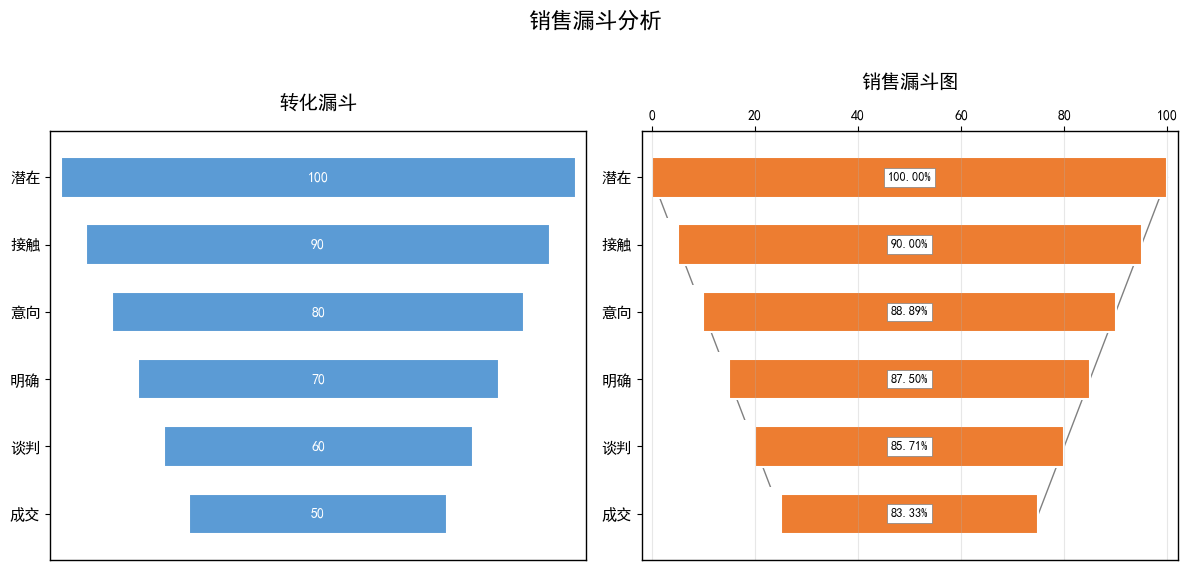

In [3]:
import matplotlib.pyplot as plt
import numpy as np
#2-1 漏斗图
# ================= 1. 全局设置 =================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ================= 2. 数据准备 =================
stages = ['潜在', '接触', '意向', '明确', '谈判', '成交']
users = np.array([100, 90, 80, 70, 60, 50])
rates = [1.0000, 0.9000, 0.8889, 0.8750, 0.8571, 0.8333]

# 核心逻辑：计算占位（辅助列），使条形居中
max_val = 100
spacer = (max_val - users) / 2
y_pos = np.arange(len(stages))

# ================= 3. 绘图 =================
# 调整 figsize，宽度稍微减小，让图更紧凑
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6)) 
fig.suptitle('销售漏斗分析', fontsize=16, fontweight='bold', y=0.95)

color_blue = '#5B9BD5'
color_orange = '#ED7D31'

# --- 图1：转化漏斗 (左图) ---
ax1.barh(y_pos, spacer, color='white', edgecolor='none')
ax1.barh(y_pos, users, left=spacer, color=color_blue, edgecolor='white', linewidth=1.5, height=0.6)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(stages, fontsize=11)
ax1.invert_yaxis()

# 添加数据标签
for i, v in enumerate(users):
    ax1.text(spacer[i] + v/2, i, str(v), ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# 将 xlim 改为 (0, 100)，图形就居中了
# 为了留一点边距，可以使用 (-2, 102)，中心依然是 50
ax1.set_xlim(-2, 102) 
ax1.set_xticks([])   
ax1.set_title('转化漏斗', fontsize=14, pad=15)
for spine in ax1.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)


# --- 图2：销售漏斗图 (右图) ---
ax2.barh(y_pos, spacer, color='white', edgecolor='none')
ax2.barh(y_pos, users, left=spacer, color=color_orange, edgecolor='white', linewidth=1.5, height=0.6)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(stages, fontsize=11)
ax2.invert_yaxis()

# 添加数据标签 (带白底框)
for i, v in enumerate(rates):
    ax2.text(spacer[i] + users[i]/2, i, f'{v:.2%}', ha='center', va='center', 
             bbox=dict(boxstyle='square,pad=0.3', facecolor='white', edgecolor='gray', linewidth=0.5), 
             fontsize=9)

# 绘制漏斗斜线
for i in range(len(stages) - 1):
    ax2.plot([spacer[i], spacer[i+1]], [i, i+1], color='gray', linewidth=1, zorder=0)
    ax2.plot([spacer[i] + users[i], spacer[i+1] + users[i+1]], [i, i+1], color='gray', linewidth=1, zorder=0)

# 【关键修改】：同样调整 xlim 为 (-2, 102) 确保居中，并设置刻度
ax2.set_xlim(-2, 102)
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')
# 设置刻度为 0, 20, 40... 100
ax2.set_xticks([0, 20, 40, 60, 80, 100])
ax2.grid(axis='x', linestyle='-', alpha=0.3, zorder=0)
ax2.set_title('销售漏斗图', fontsize=14, pad=15)
for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

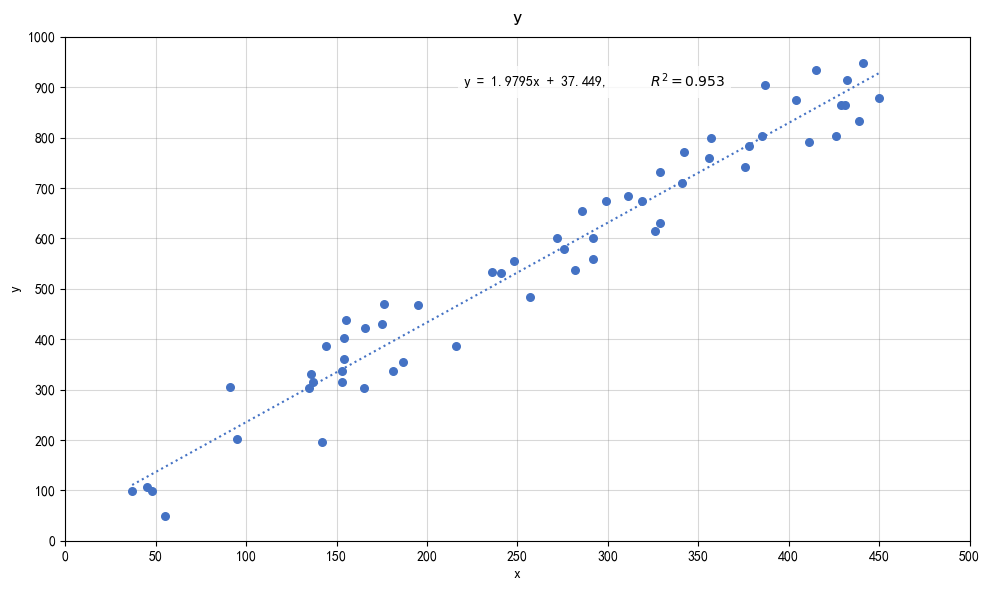

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# 3-1 相关分析
# ================= 1. 全局设置 =================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] # 支持中文
plt.rcParams['axes.unicode_minus'] = False

# ================= 2. 数据准备 =================
# 从截图中提取的部分数据 (x, y)
x_data = np.array([
    155, 272, 248, 292, 144, 329, 411, 216, 91, 195, 135, 176, 415, 257, 153, 357, 
    48, 286, 292, 431, 426, 385, 441, 236, 154, 439, 154, 387, 319, 137, 329, 432, 
    187, 136, 142, 282, 241, 181, 429, 175, 376, 165, 95, 342, 166, 341, 378, 311, 
    326, 299, 450, 276, 37, 55, 356, 404, 45, 153
])

y_data = np.array([
    438, 601, 556, 560, 387, 630, 792, 387, 306, 467, 303, 470, 935, 483, 316, 799, 
    98, 654, 601, 865, 803, 804, 948, 533, 360, 833, 402, 904, 674, 316, 731, 914, 
    354, 331, 195, 537, 532, 336, 865, 430, 741, 304, 201, 772, 423, 710, 783, 685, 
    614, 675, 878, 579, 99, 50, 760, 875, 106, 337
])

# ================= 3. 计算线性回归 =================
slope, intercept = np.polyfit(x_data, y_data, 1)
correlation_matrix = np.corrcoef(x_data, y_data)
correlation_xy = correlation_matrix[0, 1]
r_squared = correlation_xy**2

x_line = np.linspace(min(x_data), max(x_data), 100)
y_line = slope * x_line + intercept

# ================= 4. 绘图 =================
fig, ax = plt.subplots(figsize=(10, 6))

# 1. 画散点图
ax.scatter(x_data, y_data, color='#4472C4', s=30, zorder=3, label='Data Points')

# 2. 画趋势线
ax.plot(x_line, y_line, color='#4472C4', linestyle=':', linewidth=1.5, zorder=2, label='Trendline')

# 注意字符串前面的 r 表示 raw string，防止反斜杠被转义
equation_text = f'y = {slope:.4f}x + {intercept:.3f}'
r2_text = rf'$R^2 = {r_squared:.3f}$' 

# 将两个文本合并，中间加空格
full_text = f'{equation_text},      {r2_text}'

ax.text(220, 900, full_text, 
        fontsize=10, color='black', 
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)) 

# 5. 设置标题和标签
ax.set_title('y', fontsize=14, pad=10)
ax.set_xlabel('x')
ax.set_ylabel('y')

# 6. 设置坐标轴范围
ax.set_xlim(0, 500)
ax.set_ylim(0, 1000)

# 7. 设置刻度
ax.set_xticks(range(0, 501, 50))
ax.set_yticks(range(0, 1001, 100))

# 8. 添加网格线
ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)

plt.tight_layout()
plt.show()